<a href="https://colab.research.google.com/github/camiloch28/NovaMarket---analysis/blob/main/NovaMarket%20-%20analysis%20-%20Google%20Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1.  Crear scatterplot y mejorar su visualizacion

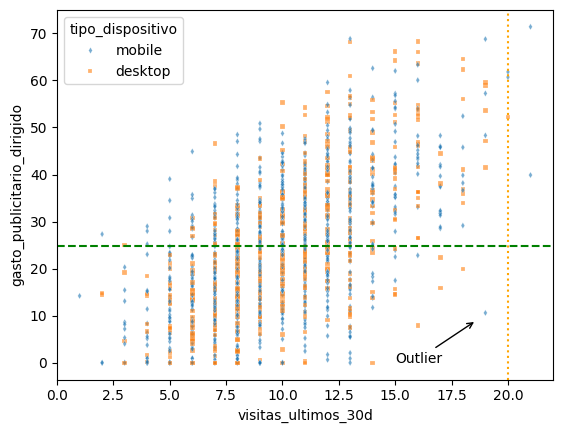

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv("/nova_market_activity.csv")

# Crear scatterplot
sns.scatterplot(data=df,x="visitas_ultimos_30d", y="gasto_publicitario_dirigido",
    hue="tipo_dispositivo",#marcadores
    style="tipo_dispositivo", #marcadores cada categoria color distinto
    markers={
        "mobile": "d",     # diamante delgado
        "desktop": "s"},    # cuadrado,
    color="mediumseagreen",
    alpha=0.6,   # transparencia
    s=10         # tamaño de puntos
    )

ax = plt.gca()
ax.annotate(
    "Outlier",         # texto a mostrar
    xy=(18.6, 9),      # coordenadas del punto
    xytext=(15,0),     # coordenadas del texto
    arrowprops=dict(arrowstyle="->")
)

plt.axhline(df["gasto_publicitario_dirigido"].mean(), color="green", linestyle="--") # linea de referencia
plt.axvline(20, color="orange", linestyle=":") # linea de referencia

plt.show()

Analisis: Se puede visualizar correlacion positiva Los puntos dibujan una tendencia ascendente, es decir, suben hacia la derecha. Es el patrón más buscado en indicadores de crecimiento.

→ Existe una relación directa: cuando el valor en el eje X aumenta, el valor en el eje Y también tiende a aumentar.

Ejemplos de negocio:

Más inversión en publicidad → Más visitas
Más horas de estudio → Mejor calificación.

Se agregan elementos para personalizar el grafico y poder entender mejor el contexto, outliers, segmentar por categoria, entre otros.

#2.1.  Construir n Heatmap con Seaborn

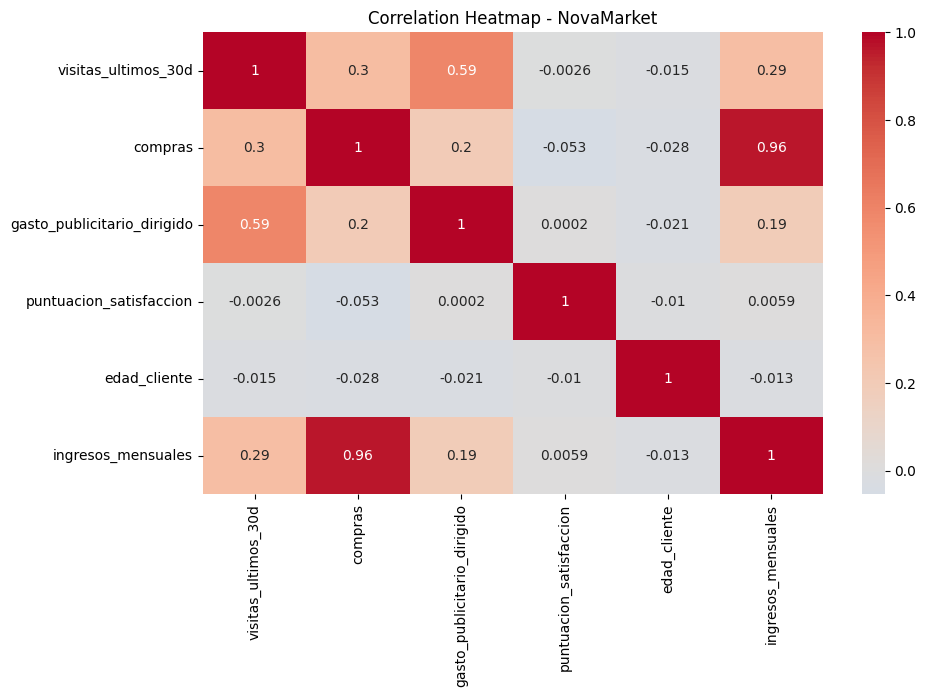

In [12]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap - NovaMarket")
plt.show()

#2.2.  Construir Scatter Plot Matrix (Pairplot).

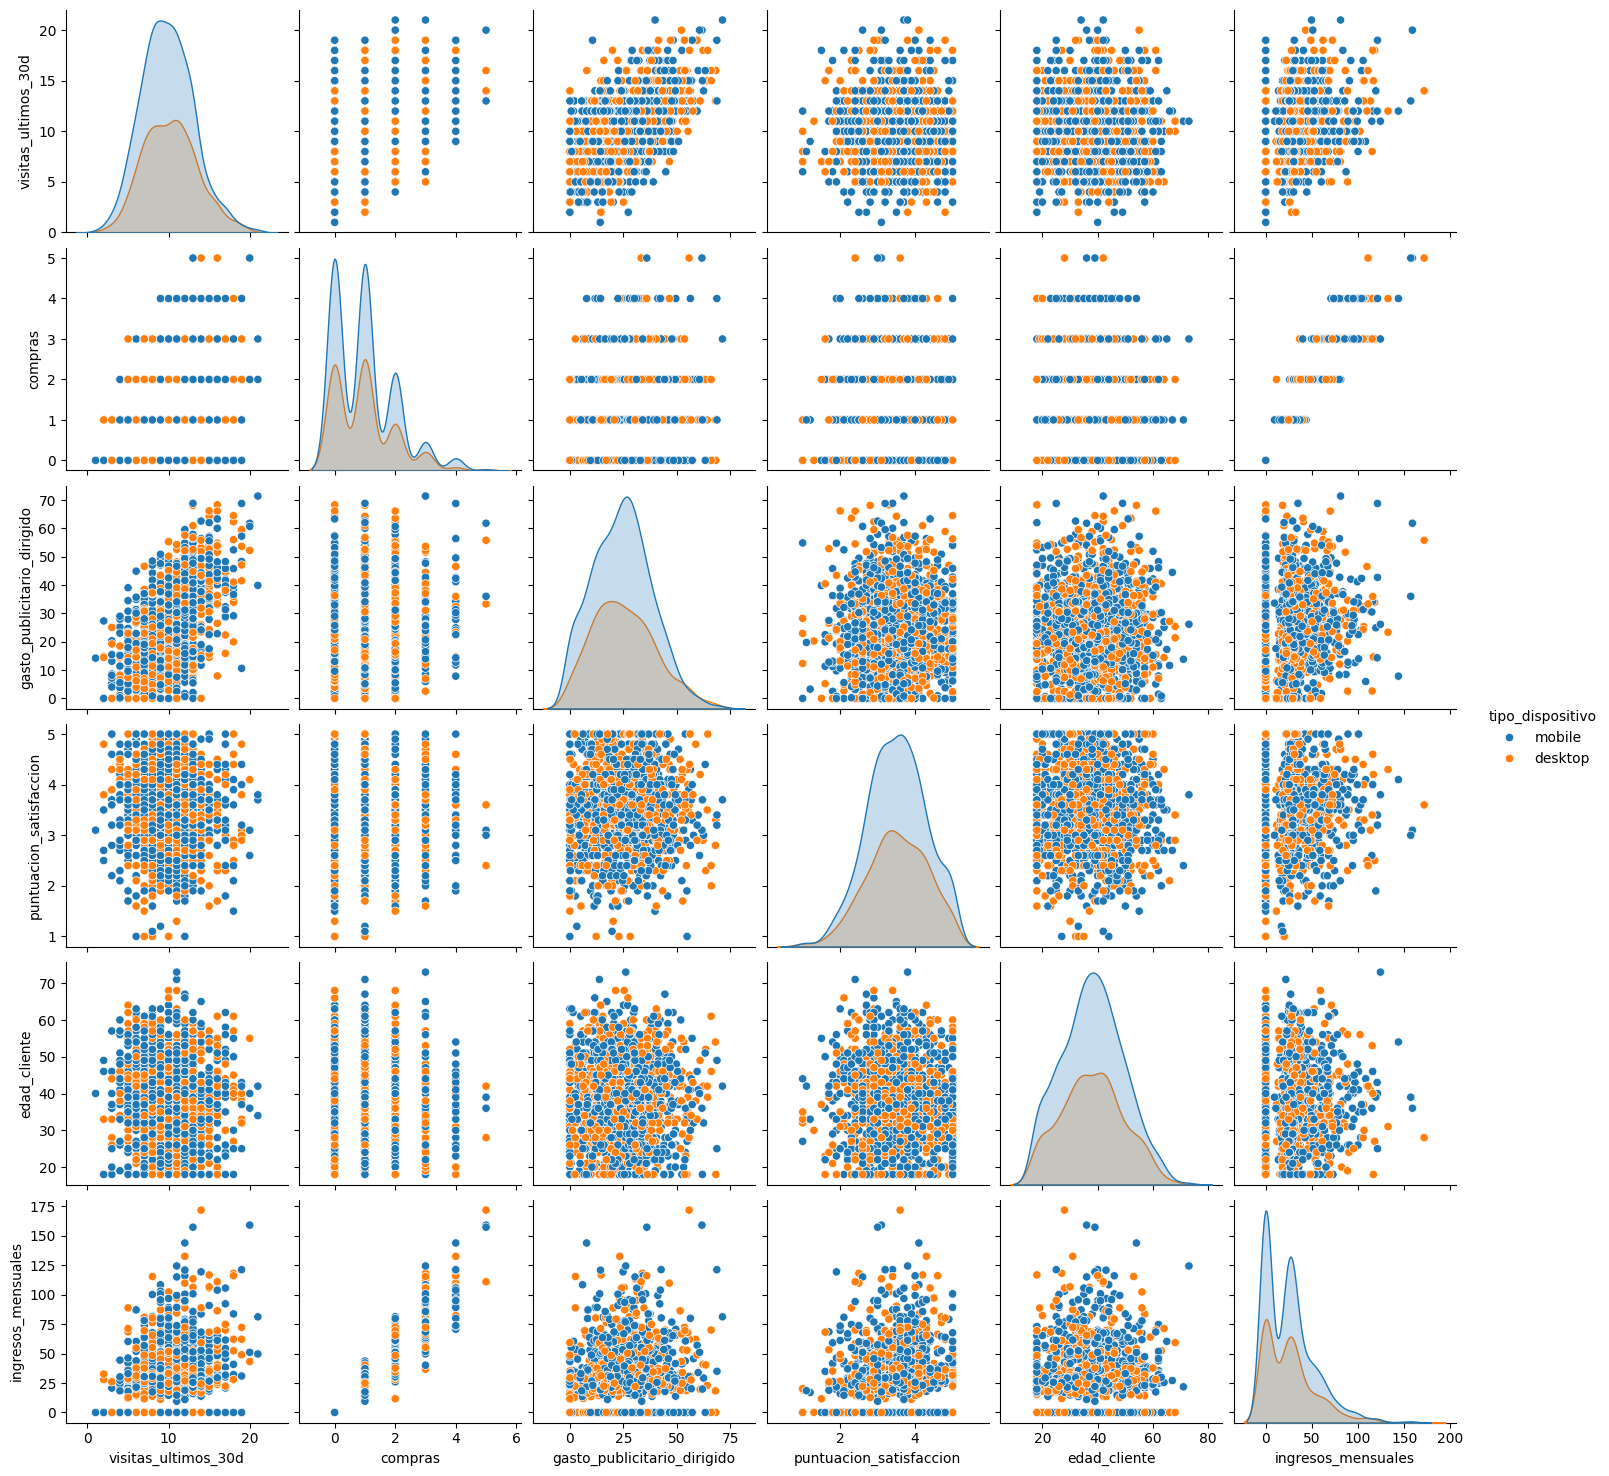

In [17]:
df = pd.read_csv("/content/nova_market_activity.csv")
sns.pairplot(df, hue="tipo_dispositivo")


#3.   Correlaciones de Pearson y Spearman


In [18]:
import pandas as pd
df = pd.read_csv('/content/nova_market_activity.csv')

# Comenzamos calculando la correlación Pearson, que nos indica qué tan lineal es la relación entre dos variables.

cols = [
'visitas_ultimos_30d',
'compras',
'gasto_publicitario_dirigido',
'puntuacion_satisfaccion',
'edad_cliente',
'ingresos_mensuales'
]

pearson = df[cols].corr(method='pearson')
pearson

,visitas_ultimos_30d,compras,gasto_publicitario_dirigido,puntuacion_satisfaccion,edad_cliente,ingresos_mensuales
visitas_ultimos_30d,1.000000,0.298568,0.590205,-0.002620,-0.015076,0.291199
compras,0.298568,1.000000,0.199835,-0.053354,-0.027733,0.960362
gasto_publicitario_dirigido,0.590205,0.199835,1.000000,0.000205,-0.020847,0.194396
puntuacion_satisfaccion,-0.002620,-0.053354,0.000205,1.000000,-0.010068,0.005851
edad_cliente,-0.015076,-0.027733,-0.020847,-0.010068,1.000000,-0.012532
ingresos_mensuales,0.291199,0.960362,0.194396,0.005851,-0.012532,1.000000


compras e ingresos_mensuales tienen una correlación de 0.96.

Esto es una
correlación muy alta y nos hace sospechar de colinealidad: ambas variables se mueven casi igual y aportan información similar.

Luego, vemos visitas con gasto_publicitario_dirigido, con una correlación de 0.59.
  Aquí la relación es positiva y moderada: cuando aumentamos la inversión en publicidad, normalmente aumentan las visitas… pero no de manera perfecta.

Finalmente, visitas con compras tiene 0.29.
  Esta es una relación débil, pero existente: más visitas no garantizan muchas compras, pero sí hay cierta conexión entre ambas.

In [19]:
# Ahora calculamos la correlación Spearman, que mide si la relación es consistente, aunque no necesariamente lineal.
spearman = df[cols].corr(method='spearman')
spearman

,visitas_ultimos_30d,compras,gasto_publicitario_dirigido,puntuacion_satisfaccion,edad_cliente,ingresos_mensuales
visitas_ultimos_30d,1.000000,0.280081,0.571214,0.001561,-0.026734,0.279708
compras,0.280081,1.000000,0.204268,-0.062993,-0.028638,0.963608
gasto_publicitario_dirigido,0.571214,0.204268,1.000000,-0.000998,-0.027956,0.203928
puntuacion_satisfaccion,0.001561,-0.062993,-0.000998,1.000000,-0.007879,0.010210
edad_cliente,-0.026734,-0.028638,-0.027956,-0.007879,1.000000,-0.019860
ingresos_mensuales,0.279708,0.963608,0.203928,0.010210,-0.019860,1.000000


Al interpretar los resultados con Spearman, vemos que:

compras contra ingresos_mensuales da 0.96, igual que en Pearson.
  Esto confirma la colinealidad: la relación es muy fuerte, estable y consistente.

Después, visitas con gasto_publicitario_dirigido tiene 0.57.
  Es prácticamente el mismo valor que Pearson; nos dice que la relación es lineal y estable.

Luego, visitas con compras tiene 0.28.
  De nuevo, casi igual que Pearson: es una relación débil, pero real y consistente.

Y finalmente, puntuacion_satisfaccion y edad_cliente muestran correlación cercana a cero. Eso significa que no hay una relación clara entre ellas, ni lineal ni consistente.

Entonces, ¿cómo interpretamos Pearson vs. Spearman?

Cuando Pearson y Spearman son similares, la relación es lineal y consistente.
  👉 Nos quedamos con Pearson.

Cuando Spearman es claramente mayor que Pearson, la relación no es lineal, pero sigue un patrón consistente.
  👉 En ese caso, Spearman describe mejor la tendencia.

En este dataset, la mayoría de las relaciones importantes son lineales, por eso ambos métodos dan valores parecidos.

<Axes: xlabel='compras', ylabel='ingresos_mensuales'>

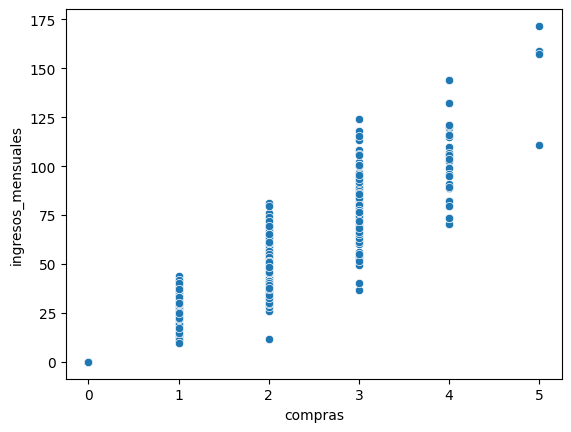

In [22]:
# Después de calcular correlaciones, siempre validamos visualmente con scatter plots.

import seaborn as sns

# Colinealidad clara
sns.scatterplot(data=df, x='compras', y='ingresos_mensuales')

En compras e ingresos_mensuales
  
  Aunque el gráfico no forme una línea recta perfecta, la tendencia es muy fuerte.
  
  Además, Pearson y Spearman son cercanos a 1, confirmando que están contando casi la misma historia.
  Por eso decimos que existe colinealidad.

<Axes: xlabel='visitas_ultimos_30d', ylabel='gasto_publicitario_dirigido'>

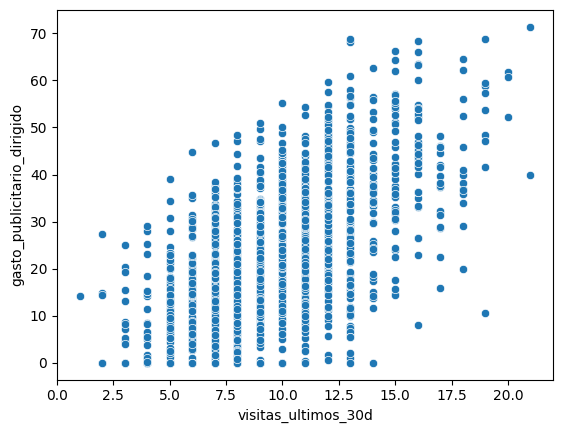

In [23]:
# Relación positiva moderada
sns.scatterplot(data=df, x='visitas_ultimos_30d', y='gasto_publicitario_dirigido')

En visitas y gasto_publicitario_dirigido
  Los puntos suben juntos de forma bastante ordenada, mostrando una relación moderadamente lineal.

 gráficos confirman lo que vimos numéricamente.

Por lo tanto, el flujo recomendado es:

Primero: calcular Pearson para detectar relaciones lineales.
Luego: calcular Spearman para confirmar si la relación es consistente, incluso si no es perfectamente lineal.

Después: graficar los pares más relevantes para validar visualmente el patrón.

Finalmente: identificar posibles casos de colinealidad.
Este proceso te permite entender mejor cómo se relacionan las variables y evitar conclusiones engañosas en tus análisis de negocio.

#Metodo de correlacion punto - biserial

In [6]:
import pandas as pd
from scipy.stats import pointbiserialr

df = pd.read_csv("/content/nova_market_activity.csv")

# Codificar Yes / No a números
df["estado_suscripcion"] = df["estado_suscripcion"].map({"Yes": 1, "No": 0 }).astype(int)

# Calcular la correlación punto-biserial
pointbiserialr( df["estado_suscripcion"], df["ingresos_mensuales"] )


#Analisis: El coeficiente de correlación es 0.063. Es un valor positivo, pero muy pequeño, lo que indica que la diferencia entre los dos grupos es débil. En palabras simples: los usuarios suscritos ganan un poco más, pero la diferencia es pequeña.

SignificanceResult(statistic=np.float64(0.06277995583007166), pvalue=np.float64(0.015022785776769035))

#Metodo de correlacion V de Cramer

In [7]:
from scipy.stats import chi2_contingency
import pandas as pd
import numpy as np

df = pd.read_csv("/content/nova_market_activity.csv")
df.head()

#Antes de calcular V de Cramer, necesitamos resumir los datos en una tabla de contingencia.
tabla = pd.crosstab(
    df["region"],
    df["tipo_dispositivo"]
)

tabla

#El valor de chi-cuadrado simplemente mide qué tan grande es esa diferencia.
chi2, p, dof, expected = chi2_contingency(tabla)
chi2

#La fórmula que ves aquí es una transformación que nos permite leer e interpretar mejor los resultados.
n = tabla.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(tabla.shape) -1)))
cramers_v


#Analisis: El resultado es un valor cercano a cero, lo que indica que la asociación entre región y tipo de dispositivo es muy débil. En otras palabras, el dispositivo que usan los usuarios no varía de forma relevante según la región, por lo que no hay un patrón que justifique estrategias distintas por región.



np.float64(0.05301303158284989)